In [14]:
import os
import sys
from pathlib import Path
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

# Add src to path for editable installs (optional)
repo_root = Path.cwd()
while repo_root != repo_root.parent:
    src_path = repo_root / "src"
    if (src_path / "jorg").exists():
        sys.path.insert(0, str(src_path))
        data_dir = repo_root / "data"
        if data_dir.exists():
            os.environ.setdefault("JORG_DATA_DIR", str(data_dir))
        break
    repo_root = repo_root.parent


# Jorg Tutorial: Jorg vs Korg Module Comparison and Speed

This notebook compares Jorg and Korg at the module level and provides speed benchmarks
that scale with `n_pixel * n_spectra`.


## 1. Basic Synthesis with Jorg

The standard `synth()` function is the main entry point. It computes a stellar spectrum given:
- Teff: effective temperature [K]
- logg: surface gravity (log g)
- m_H: metallicity [M/H]


📖 Reading linelist: vald_extract_stellar_solar_threshold001.vald
   Format: vald
   Wavelength unit: auto
   Detected vacuum wavelengths - no conversion needed
   Found 41880 data lines
   Successfully parsed 41861 lines
   After Korg.jl filtering: 41861 lines (removed 0 lines)
Loaded 41861 spectral lines
Synthesis time: 3.08s
Wavelength points: 201


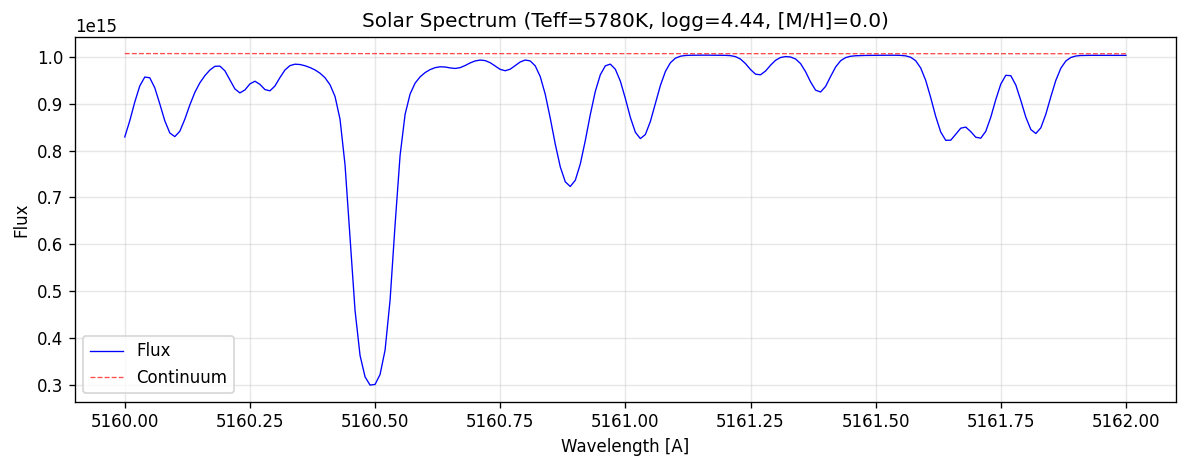

In [15]:
from jorg.synthesis import synth
from jorg.lines.linelist_data import get_VALD_solar_linelist

# Load the built-in VALD solar linelist
linelist = get_VALD_solar_linelist()
print(f"Loaded {len(linelist)} spectral lines")

# Solar parameters
Teff = 5780  # K
logg = 4.44
m_H = 0.0    # Solar metallicity

# Synthesize a small wavelength region
wl_range_basic = (5160.0, 5162.0)

t0 = time.perf_counter()
wl, flux, cont = synth(
    Teff, logg, m_H,
    wavelengths=wl_range_basic,
    linelist=linelist,
    rectify=False,
    hydrogen_lines=False,
    verbose=False,
)
t1 = time.perf_counter()

print(f"Synthesis time: {t1-t0:.2f}s")
print(f"Wavelength points: {len(wl)}")

# Plot (physical flux + continuum)
plt.figure(figsize=(10, 4), dpi=120)
plt.plot(wl, flux, "b-", lw=0.8, label="Flux")
plt.plot(wl, cont, "r--", lw=0.8, alpha=0.7, label="Continuum")
plt.xlabel("Wavelength [A]")
plt.ylabel("Flux")
plt.title(f"Solar Spectrum (Teff={Teff}K, logg={logg}, [M/H]={m_H})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 2. Vectorized Radiative Transfer (Jorg)

Jorg uses vectorized radiative transfer kernels (JAX) to process all wavelengths and
mu-angles together. This section benchmarks the core JAX RT kernel.


In [16]:
import jax.numpy as jnp
from jorg.radiative_transfer_exact import (
    compute_I_linear_batch,
    generate_mu_grid,
    compute_I_linear_mu,
)

# Create test data: 56 atmospheric layers, 1000 wavelength points
n_layers = 56
n_wavelengths = 1000

# Random optical depth (increasing with layer depth)
np.random.seed(42)
tau_matrix = jnp.cumsum(jnp.abs(np.random.randn(n_layers, n_wavelengths) * 0.1), axis=0)
source_matrix = jnp.ones((n_layers, n_wavelengths)) * 1.0

# Angular quadrature grid
mu_values, mu_weights = generate_mu_grid(20)
print(f"mu grid: {len(mu_values)} points from {float(mu_values.min()):.3f} to {float(mu_values.max()):.3f}")

# Warm up JIT compilation
_ = compute_I_linear_batch(tau_matrix, source_matrix, mu_values).block_until_ready()

# Benchmark vectorized version
t0 = time.perf_counter()
for _ in range(10):
    intensity = compute_I_linear_batch(tau_matrix, source_matrix, mu_values).block_until_ready()
t_vectorized = (time.perf_counter() - t0) / 10

print("")
print("Vectorized RT:")
print(f"  Output shape: {intensity.shape}  (n_mu, n_layers, n_wavelengths)")
print(f"  Time per call: {t_vectorized*1000:.2f} ms")
print(f"  Throughput: {n_wavelengths * len(mu_values) / t_vectorized:.0f} (wl x mu)/s")


mu grid: 20 points from 0.003 to 0.997

Vectorized RT:
  Output shape: (20, 56, 1000)  (n_mu, n_layers, n_wavelengths)
  Time per call: 12.24 ms
  Throughput: 1634608 (wl x mu)/s


## 3. Custom Abundances

You can specify individual element abundances relative to solar values.


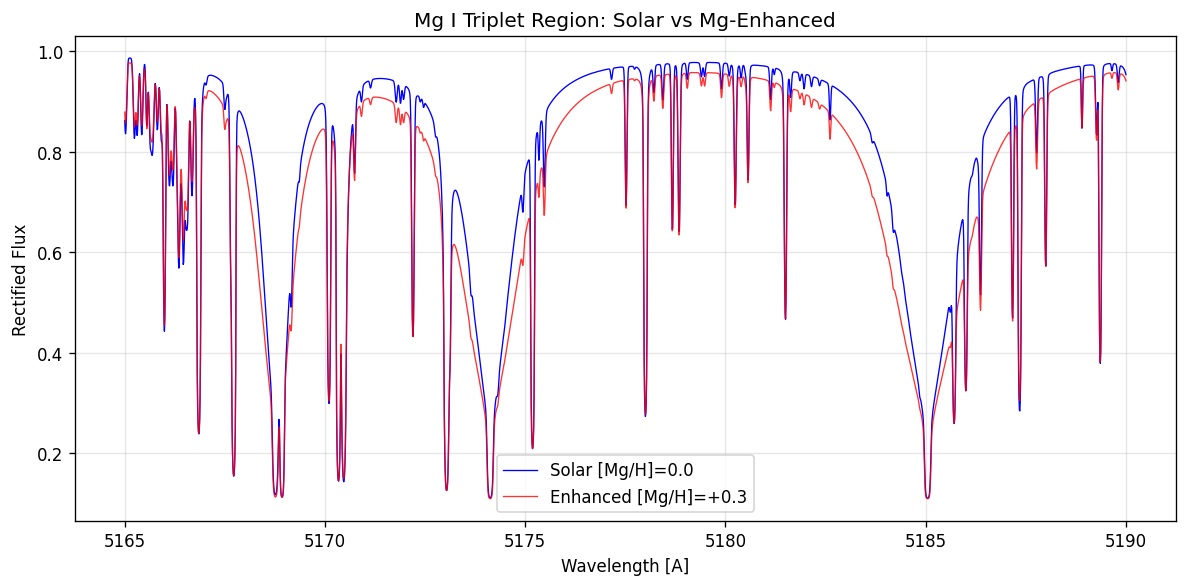

In [17]:
# Compare solar vs enhanced magnesium
wl_solar, flux_solar, cont_solar = synth(
    5780, 4.44, 0.0,
    wavelengths=(5165, 5190),
    linelist=linelist,
    rectify=False,
    hydrogen_lines=False,
    verbose=False,
)

# Enhanced Mg (+0.3 dex)
wl_mg, flux_mg, cont_mg = synth(
    5780, 4.44, 0.0,
    wavelengths=(5165, 5190),
    linelist=linelist,
    Mg=0.3,  # [Mg/H] = +0.3
    rectify=False,
    hydrogen_lines=False,
    verbose=False,
)

plt.figure(figsize=(10, 5), dpi=120)
plt.plot(wl_solar, flux_solar / cont_solar, "b-", lw=0.8, label="Solar [Mg/H]=0.0")
plt.plot(wl_mg, flux_mg / cont_mg, "r-", lw=0.8, alpha=0.8, label="Enhanced [Mg/H]=+0.3")
plt.xlabel("Wavelength [A]")
plt.ylabel("Rectified Flux")
plt.title("Mg I Triplet Region: Solar vs Mg-Enhanced")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Module-Level Comparison: Jorg vs Korg

This section compares Jorg outputs to Korg reference data at multiple stages:
- Atmosphere interpolation
- Continuum-only opacity (summary stats)
- With-lines opacity (summary stats)
- Radiative transfer (continuum-only and with-lines spectra)

Reference data lives in `examples/korg_reference` and is precomputed by Korg.


In [18]:
REFERENCE_DIR = repo_root / "examples" / "korg_reference"

KORG_FILES = {
    "Solar": {
        "atmosphere": "korg_solar_atmosphere.txt",
        "spectrum_continuum": "korg_solar_continuum_only.txt",
        "spectrum_lines": "korg_solar_with_lines.txt",
        "opacity_continuum": "korg_solar_opacity_continuum.txt",
        "opacity_with_lines": "korg_solar_opacity_with_lines.txt",
    },
    "Arcturus": {
        "atmosphere": "korg_arcturus_atmosphere.txt",
        "spectrum_continuum": "korg_arcturus_continuum_only.txt",
        "spectrum_lines": "korg_arcturus_with_lines.txt",
        "opacity_continuum": "korg_arcturus_opacity_continuum.txt",
        "opacity_with_lines": "korg_arcturus_opacity_with_lines.txt",
    },
    "Metal-poor": {
        "atmosphere": "korg_metal_poor_k_giant_atmosphere.txt",
        "spectrum_continuum": "korg_metal_poor_k_giant_continuum_only.txt",
        "spectrum_lines": "korg_metal_poor_k_giant_with_lines.txt",
        "opacity_continuum": "korg_metal_poor_k_giant_opacity_continuum.txt",
        "opacity_with_lines": "korg_metal_poor_k_giant_opacity_with_lines.txt",
    },
}


def _parse_params_from_header(lines):
    params = {}
    for line in lines:
        if not line.startswith("#"):
            break
        if "Parameters:" in line:
            parts = line.split("Parameters:")[1].strip()
            for p in parts.split(","):
                p = p.strip()
                if p.startswith("Teff="):
                    params["Teff"] = float(p.split("=")[1].rstrip("K"))
                elif p.startswith("logg="):
                    params["logg"] = float(p.split("=")[1])
                elif "[M/H]=" in p:
                    params["m_H"] = float(p.split("=")[1])
        if "Synthesis time:" in line:
            params["korg_time"] = float(line.split(":")[1].strip().split()[0])
    return params


def load_korg_reference_spectrum(filename):
    filepath = REFERENCE_DIR / filename
    with open(filepath, "r") as f:
        lines = f.readlines()
    params = _parse_params_from_header(lines)
    data = np.loadtxt(filepath, comments="#")
    return {
        "wavelength": data[:, 0],
        "flux": data[:, 1],
        "continuum": data[:, 2],
        "normalized": data[:, 3],
        **params,
    }


def load_korg_reference_atmosphere(filename):
    filepath = REFERENCE_DIR / filename
    with open(filepath, "r") as f:
        lines = f.readlines()
    params = _parse_params_from_header(lines)
    data = np.loadtxt(filepath, comments="#")
    return {
        "layer": data[:, 0].astype(int),
        "temperature": data[:, 1],
        "electron_density": data[:, 2],
        "number_density": data[:, 3],
        **params,
    }


def load_korg_opacity_summary(filename):
    filepath = REFERENCE_DIR / filename
    data = np.loadtxt(filepath, comments="#")
    return {
        "layer": data[:, 0].astype(int),
        "min": data[:, 1],
        "max": data[:, 2],
        "mean": data[:, 3],
    }


korg_refs = {}
for name, files in KORG_FILES.items():
    korg_refs[name] = {
        "atmosphere": load_korg_reference_atmosphere(files["atmosphere"]),
        "spectrum_continuum": load_korg_reference_spectrum(files["spectrum_continuum"]),
        "spectrum_lines": load_korg_reference_spectrum(files["spectrum_lines"]),
        "opacity_continuum": load_korg_opacity_summary(files["opacity_continuum"]),
        "opacity_with_lines": load_korg_opacity_summary(files["opacity_with_lines"]),
    }

print("Loaded Korg reference data:")
for name, ref in korg_refs.items():
    params = ref["spectrum_lines"]
    print(f"  {name}: Teff={params['Teff']:.0f}K, logg={params['logg']:.2f}, [M/H]={params['m_H']:.1f}")


Loaded Korg reference data:
  Solar: Teff=5771K, logg=4.44, [M/H]=0.0
  Arcturus: Teff=4250K, logg=1.40, [M/H]=-0.5
  Metal-poor: Teff=4500K, logg=1.50, [M/H]=-2.5


In [19]:
from jorg.atmosphere import interpolate_marcs
from jorg.opacity.layer_processor import LayerProcessor
from jorg.synthesis import (
    _calculate_line_opacity_multilayer,
    _calculate_radiative_transfer,
    create_korg_compatible_abundance_array,
)
from jorg.statmech import (
    create_default_partition_functions,
    create_default_ionization_energies,
    create_default_log_equilibrium_constants,
)
from jorg.radiative_transfer_exact import generate_mu_grid


# Shared atomic data (avoid recomputing for each call)
PARTITION_FUNCS = create_default_partition_functions()
IONIZATION_ENERGIES = create_default_ionization_energies()
LOG_EQUILIBRIUM_CONSTANTS = create_default_log_equilibrium_constants()
MU_VALUES, MU_WEIGHTS = generate_mu_grid(20)
MU_GRID = list(np.array(MU_VALUES))


def build_atm_dict(atm):
    if hasattr(atm, "layers"):
        atm_dict = {
            "temperature": np.array([layer.temp for layer in atm.layers]),
            "electron_density": np.array([layer.electron_number_density for layer in atm.layers]),
            "number_density": np.array([layer.number_density for layer in atm.layers]),
            "tau_5000": np.array([layer.tau_5000 for layer in atm.layers]),
            "height": np.array([layer.z for layer in atm.layers]),
        }
        atm_dict["pressure"] = atm_dict["number_density"] * 1.380649e-16 * atm_dict["temperature"]
        return atm_dict
    return atm


def summarize_opacity(alpha_matrix):
    return {
        "min": alpha_matrix.min(axis=1),
        "max": alpha_matrix.max(axis=1),
        "mean": alpha_matrix.mean(axis=1),
    }


def compare_opacity_summary(jorg_summary, korg_summary):
    def rel_err(a, b):
        denom = np.maximum(np.abs(b), 1e-30)
        return np.abs(a - b) / denom

    # Align lengths if needed
    n = min(len(jorg_summary["mean"]), len(korg_summary["mean"]))

    metrics = {}
    for key in ["min", "max", "mean"]:
        r = rel_err(jorg_summary[key][:n], korg_summary[key][:n])
        metrics[f"{key}_rel_mean"] = float(np.mean(r))
        metrics[f"{key}_rel_max"] = float(np.max(r))
    return metrics


def compare_atmosphere(jorg_atm, korg_atm):
    def stats(a, b):
        n = min(len(a), len(b))
        a = np.asarray(a[:n])
        b = np.asarray(b[:n])
        diff = a - b
        return {
            "mae": float(np.mean(np.abs(diff))),
            "rms": float(np.sqrt(np.mean(diff ** 2))),
            "max": float(np.max(np.abs(diff))),
        }

    return {
        "temperature": stats(jorg_atm["temperature"], korg_atm["temperature"]),
        "electron_density": stats(jorg_atm["electron_density"], korg_atm["electron_density"]),
        "number_density": stats(jorg_atm["number_density"], korg_atm["number_density"]),
    }


def compare_spectrum(jorg_flux, jorg_cont, korg_norm):
    norm_jorg = jorg_flux / jorg_cont
    residual = norm_jorg - korg_norm
    return {
        "mae": float(np.mean(np.abs(residual))),
        "rms": float(np.sqrt(np.mean(residual ** 2))),
        "max": float(np.max(np.abs(residual))),
        "agreement_1pct": float(100 * np.mean(np.abs(residual) < 0.01)),
        "residual": residual,
        "norm_jorg": norm_jorg,
    }


def run_jorg_pipeline(
    Teff,
    logg,
    m_H,
    wl_array,
    linelist,
    hydrogen_lines=False,
    cntm_step=1.0,
    vmic=1.0,
    line_buffer=10.0,
    rt_method="korg_default",
    compute_continuum=False,
):
    timings = {}

    t0 = time.perf_counter()
    atm = interpolate_marcs(Teff, logg, m_H)
    timings["atmosphere"] = time.perf_counter() - t0

    atm_dict = build_atm_dict(atm)
    A_X = create_korg_compatible_abundance_array(m_H)

    abs_abundances = 10 ** (A_X - 12)
    abs_abundances = abs_abundances / np.sum(abs_abundances)
    abs_abundances_dict = {Z: abs_abundances[Z - 1] for Z in range(1, 93)}

    layer_processor = LayerProcessor(
        ionization_energies=IONIZATION_ENERGIES,
        partition_funcs=PARTITION_FUNCS,
        log_equilibrium_constants=LOG_EQUILIBRIUM_CONSTANTS,
        line_cutoff_threshold=3e-4,
        verbose=False,
    )

    stage1_kwargs = dict(
        atm=atm_dict,
        abs_abundances=abs_abundances_dict,
        wl_array=wl_array,
        linelist=None,
        line_buffer=line_buffer,
        hydrogen_lines=hydrogen_lines,
        vmic=vmic,
        log_g=logg,
        cntm_step=cntm_step,
    )

    t1 = time.perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        alpha_continuum, all_number_densities, all_electron_densities = layer_processor.process_all_layers(
            **stage1_kwargs,
            use_chemical_equilibrium_from=None,
        )
    timings["chem_eq_continuum"] = time.perf_counter() - t1

    t2 = time.perf_counter()
    if linelist is None:
        line_opacity = np.zeros_like(alpha_continuum)
    else:
        line_opacity = _calculate_line_opacity_multilayer(
            wl_array=wl_array,
            temps=np.array(atm_dict["temperature"]),
            electron_densities=all_electron_densities,
            number_densities=all_number_densities,
            partition_funcs=PARTITION_FUNCS,
            linelist=linelist,
            line_buffer=line_buffer,
            microturbulence_kms=vmic,
            continuum_opacity=alpha_continuum,
            cutoff_threshold=3e-4,
            verbose=False,
        )
    timings["line_opacity"] = time.perf_counter() - t2

    alpha_total = alpha_continuum + line_opacity

    t3 = time.perf_counter()
    flux, continuum, intensity, source = _calculate_radiative_transfer(
        alpha_total,
        atm_dict,
        wl_array,
        MU_GRID,
        "linear_flux_only",
        True,
        A_X,
        layer_processor,
        linelist,
        line_buffer,
        hydrogen_lines,
        vmic,
        abs_abundances,
        None,
        logg,
        False,
        rt_method=rt_method,
        verbose=False,
        alpha_continuum=alpha_continuum,
        line_cutoff_threshold=3e-4,
    )
    timings["radiative_transfer"] = time.perf_counter() - t3

    continuum_flux = None
    continuum_cont = None
    if compute_continuum:
        t4 = time.perf_counter()
        continuum_flux, continuum_cont, _, _ = _calculate_radiative_transfer(
            alpha_continuum,
            atm_dict,
            wl_array,
            MU_GRID,
            "linear_flux_only",
            True,
            A_X,
            layer_processor,
            [],
            line_buffer,
            hydrogen_lines,
            vmic,
            abs_abundances,
            None,
            logg,
            False,
            rt_method=rt_method,
            verbose=False,
            alpha_continuum=alpha_continuum,
            line_cutoff_threshold=3e-4,
        )
        timings["radiative_transfer_continuum"] = time.perf_counter() - t4

    return {
        "atm": atm,
        "atm_dict": atm_dict,
        "alpha_continuum": alpha_continuum,
        "line_opacity": line_opacity,
        "alpha_total": alpha_total,
        "flux": flux,
        "continuum": continuum,
        "continuum_flux": continuum_flux,
        "continuum_cont": continuum_cont,
        "timings": timings,
    }


In [20]:
# Compare Jorg vs Korg for each star
# Set to None for full 5000-5020 A (2001 points). Use a narrow range for speed.
COMPARE_WL_RANGE = None

if COMPARE_WL_RANGE is not None:
    print("Note: opacity summary comparisons use full-range Korg references; subset comparisons are approximate.")

comparison_results = {}

for name, ref in korg_refs.items():
    korg_spec = ref["spectrum_lines"]
    wl_full = korg_spec["wavelength"]

    if COMPARE_WL_RANGE is None:
        mask = np.ones_like(wl_full, dtype=bool)
    else:
        wl_min, wl_max = COMPARE_WL_RANGE
        mask = (wl_full >= wl_min) & (wl_full <= wl_max)

    wl_array = wl_full[mask]

    params = korg_spec
    print("")
    print(f"--- {name} ---")
    print(f"Teff={params['Teff']:.0f}K, logg={params['logg']:.2f}, [M/H]={params['m_H']:.1f}")

    jorg = run_jorg_pipeline(
        params["Teff"],
        params["logg"],
        params["m_H"],
        wl_array,
        linelist,
        hydrogen_lines=False,
        cntm_step=1.0,
        compute_continuum=True,
    )

    jorg_atm = build_atm_dict(jorg["atm"])
    atm_metrics = compare_atmosphere(jorg_atm, ref["atmosphere"])

    jorg_opacity_cont = summarize_opacity(jorg["alpha_continuum"])
    jorg_opacity_lines = summarize_opacity(jorg["alpha_total"])

    opacity_cont_metrics = compare_opacity_summary(jorg_opacity_cont, ref["opacity_continuum"])
    opacity_lines_metrics = compare_opacity_summary(jorg_opacity_lines, ref["opacity_with_lines"])

    # Spectrum comparison (with lines)
    korg_norm = ref["spectrum_lines"]["normalized"][mask]
    spec_metrics = compare_spectrum(jorg["flux"], jorg["continuum"], korg_norm)

    # Continuum-only spectrum comparison
    korg_cont_norm = ref["spectrum_continuum"]["normalized"][mask]
    cont_metrics = compare_spectrum(jorg["continuum_flux"], jorg["continuum_cont"], korg_cont_norm)

    comparison_results[name] = {
        "wl": wl_array,
        "korg_norm": korg_norm,
        "jorg_norm": spec_metrics["norm_jorg"],
        "residual": spec_metrics["residual"],
        "atm_metrics": atm_metrics,
        "opacity_cont_metrics": opacity_cont_metrics,
        "opacity_lines_metrics": opacity_lines_metrics,
        "spec_metrics": spec_metrics,
        "cont_metrics": cont_metrics,
        "timings": jorg["timings"],
        "korg_time": ref["spectrum_lines"].get("korg_time", None),
    }

    print("Atmosphere MAE (T, ne, nt):")
    print(f"  T: {atm_metrics['temperature']['mae']:.3e}")
    print(f"  ne: {atm_metrics['electron_density']['mae']:.3e}")
    print(f"  nt: {atm_metrics['number_density']['mae']:.3e}")
    print("Opacity summary (mean relative error):")
    print(f"  Continuum: {opacity_cont_metrics['mean_rel_mean']:.3e}")
    print(f"  With lines: {opacity_lines_metrics['mean_rel_mean']:.3e}")
    print("Spectrum (with lines):")
    print(f"  MAE: {spec_metrics['mae']:.6f} | RMS: {spec_metrics['rms']:.6f} | Max: {spec_metrics['max']:.6f}")
    print(f"  Within 1%: {spec_metrics['agreement_1pct']:.1f}%")



--- Solar ---
Teff=5771K, logg=4.44, [M/H]=0.0
Atmosphere MAE (T, ne, nt):
  T: 2.259e-03
  ne: 4.055e+12
  nt: 3.166e+10
Opacity summary (mean relative error):
  Continuum: 9.795e-05
  With lines: 2.177e-03
Spectrum (with lines):
  MAE: 0.000165 | RMS: 0.000363 | Max: 0.006290
  Within 1%: 100.0%

--- Arcturus ---
Teff=4250K, logg=1.40, [M/H]=-0.5
Atmosphere MAE (T, ne, nt):
  T: 9.600e-05
  ne: 2.228e+10
  nt: 2.203e+09
Opacity summary (mean relative error):
  Continuum: 8.350e-04
  With lines: 3.254e-04
Spectrum (with lines):
  MAE: 0.001741 | RMS: 0.004513 | Max: 0.108418
  Within 1%: 99.7%

--- Metal-poor ---
Teff=4500K, logg=1.50, [M/H]=-2.5
Atmosphere MAE (T, ne, nt):
  T: 8.719e-05
  ne: 1.259e+10
  nt: 1.509e+09
Opacity summary (mean relative error):
  Continuum: 1.741e-03
  With lines: 1.298e-03
Spectrum (with lines):
  MAE: 0.000333 | RMS: 0.001073 | Max: 0.005780
  Within 1%: 100.0%


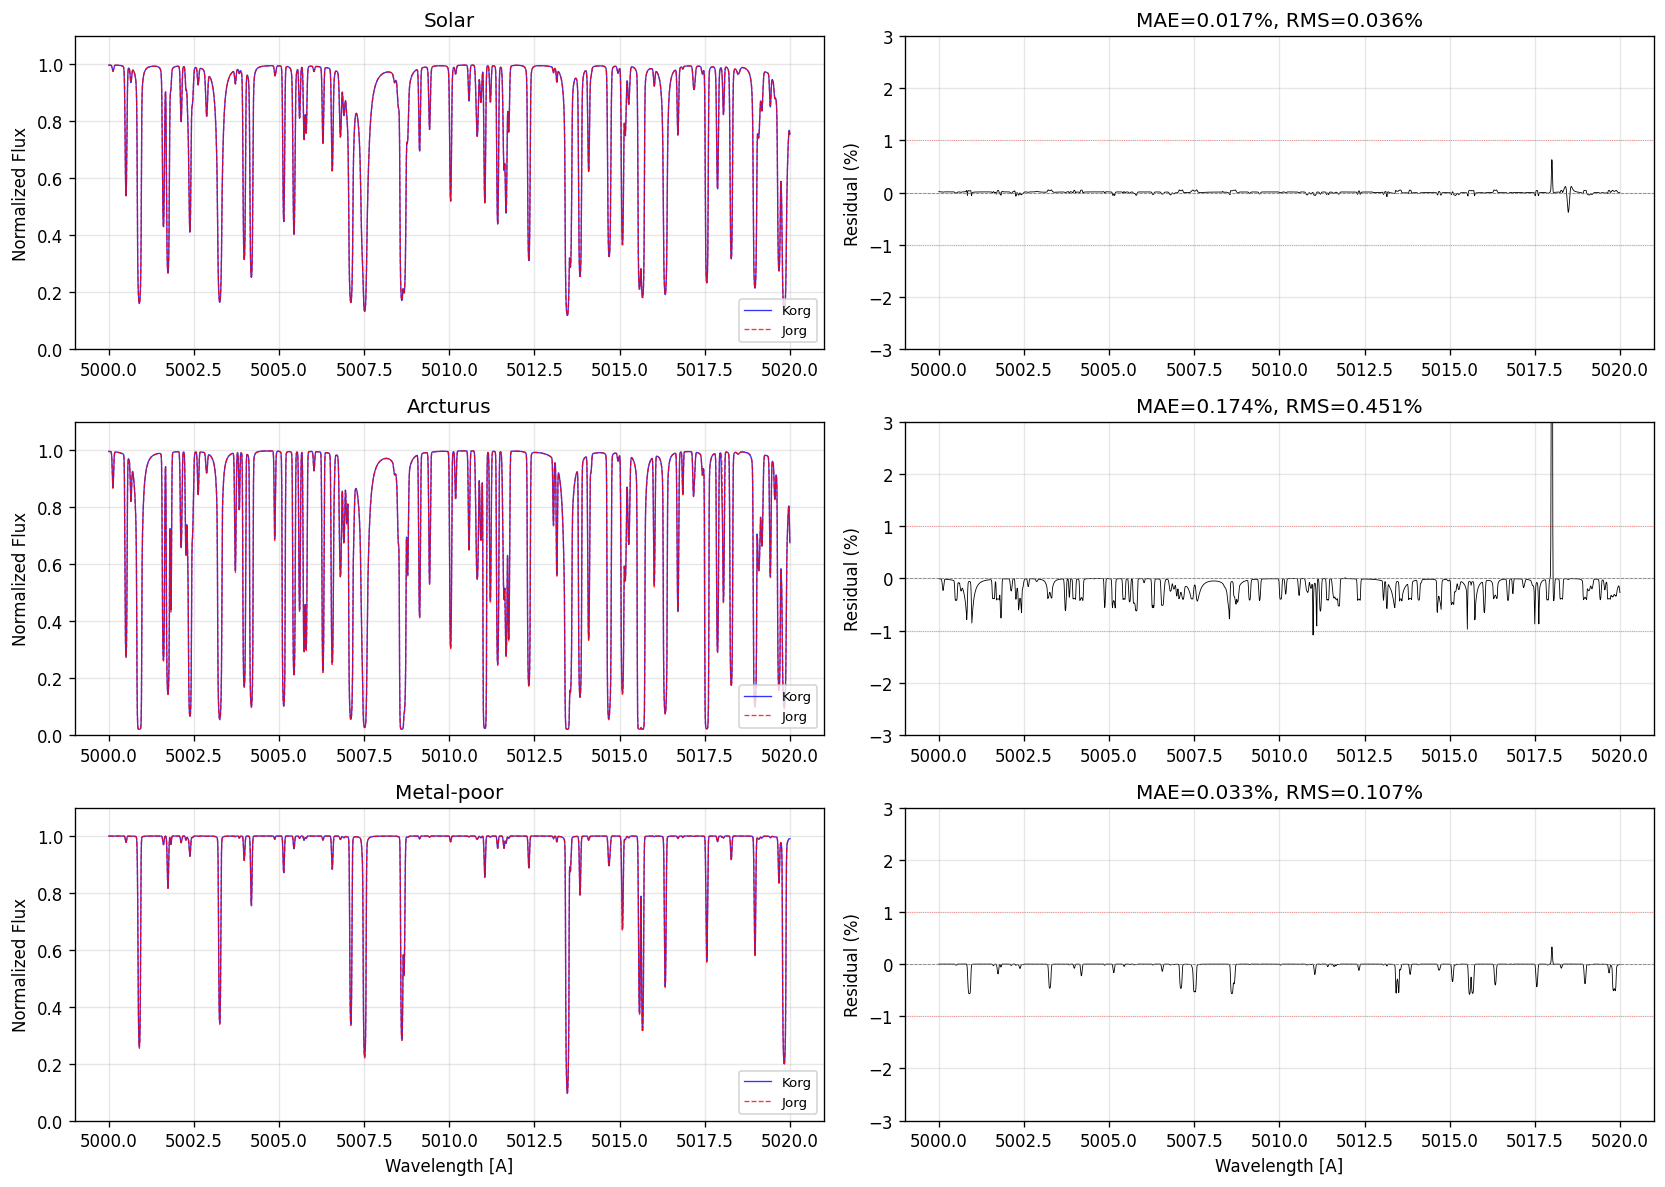

In [21]:
# Plot comparison: Jorg vs Korg (with lines)
fig, axes = plt.subplots(3, 2, figsize=(14, 10), dpi=120)

for i, name in enumerate(["Solar", "Arcturus", "Metal-poor"]):
    res = comparison_results[name]
    wl = res["wl"]

    # Left panel: spectra overlay
    ax1 = axes[i, 0]
    ax1.plot(wl, res["korg_norm"], "b-", lw=0.8, label="Korg", alpha=0.8)
    ax1.plot(wl, res["jorg_norm"], "r--", lw=0.8, label="Jorg", alpha=0.8)
    ax1.set_ylabel("Normalized Flux")
    ax1.set_title(name)
    ax1.legend(loc="lower right", fontsize=8)
    ax1.grid(alpha=0.3)
    ax1.set_ylim(0, 1.1)

    # Right panel: residuals
    ax2 = axes[i, 1]
    ax2.plot(wl, res["residual"] * 100, "k-", lw=0.5)
    ax2.axhline(0, color="gray", linestyle="--", lw=0.5)
    ax2.axhline(1, color="red", linestyle=":", lw=0.5, alpha=0.5)
    ax2.axhline(-1, color="red", linestyle=":", lw=0.5, alpha=0.5)
    ax2.set_ylabel("Residual (%)")
    ax2.set_title(
        f"MAE={res['spec_metrics']['mae']*100:.3f}%, RMS={res['spec_metrics']['rms']*100:.3f}%"
    )
    ax2.grid(alpha=0.3)
    ax2.set_ylim(-3, 3)

# Set x-labels only on bottom row
for ax in axes[-1, :]:
    ax.set_xlabel("Wavelength [A]")

plt.tight_layout()
plt.show()


## 5. Speed Benchmarks: n_pixel * n_spectra

This section benchmarks each step in the Jorg pipeline as a function of
- `n_pixel`: number of wavelength points
- `n_spectra`: number of spectra evaluated

By default this uses a small grid to keep runtime reasonable. Increase the lists
for more exhaustive benchmarking.


In [22]:
# Benchmark configuration
BENCH_WL_RANGE = (5000.0, 5020.0)
PIXEL_LIST = [200, 1000, 2001]
SPECTRA_LIST = [1, 3]

PARAM_GRID = [
    {"Teff": 5771.0, "logg": 4.44, "m_H": 0.0},
    {"Teff": 4250.0, "logg": 1.40, "m_H": -0.5},
    {"Teff": 4500.0, "logg": 1.50, "m_H": -2.5},
    {"Teff": 5000.0, "logg": 4.00, "m_H": -0.5},
    {"Teff": 6000.0, "logg": 4.50, "m_H": 0.2},
]


def build_spectra_params(n):
    params = []
    for i in range(n):
        params.append(PARAM_GRID[i % len(PARAM_GRID)])
    return params


def benchmark_jorg_steps():
    results = []

    # Warmup run to reduce one-time effects
    wl_warm = np.linspace(BENCH_WL_RANGE[0], BENCH_WL_RANGE[1], 200)
    _ = run_jorg_pipeline(
        PARAM_GRID[0]["Teff"],
        PARAM_GRID[0]["logg"],
        PARAM_GRID[0]["m_H"],
        wl_warm,
        linelist,
        hydrogen_lines=False,
        cntm_step=1.0,
        compute_continuum=False,
    )

    for n_pix in PIXEL_LIST:
        wl_array = np.linspace(BENCH_WL_RANGE[0], BENCH_WL_RANGE[1], n_pix)
        for n_spec in SPECTRA_LIST:
            params_list = build_spectra_params(n_spec)
            totals = {
                "atmosphere": 0.0,
                "chem_eq_continuum": 0.0,
                "line_opacity": 0.0,
                "radiative_transfer": 0.0,
            }

            for p in params_list:
                res = run_jorg_pipeline(
                    p["Teff"],
                    p["logg"],
                    p["m_H"],
                    wl_array,
                    linelist,
                    hydrogen_lines=False,
                    cntm_step=1.0,
                    compute_continuum=False,
                )
                for key in totals:
                    totals[key] += res["timings"][key]

            total_time = sum(totals.values())
            results.append({
                "n_pix": n_pix,
                "n_spec": n_spec,
                "pixels_total": n_pix * n_spec,
                **totals,
                "total": total_time,
                "pixels_per_sec": (n_pix * n_spec) / max(total_time, 1e-12),
            })
    return results


bench_results = benchmark_jorg_steps()

# Print summary table
print("")
print("Jorg per-step timing (seconds):")
print(f"{'n_pix':>6} {'n_spec':>6} {'pix_total':>10} {'atm':>8} {'ce+cntm':>10} {'line':>8} {'rt':>8} {'total':>9} {'pix/s':>10}")
print("-" * 85)
for r in bench_results:
    print(
        f"{r['n_pix']:>6} {r['n_spec']:>6} {r['pixels_total']:>10} "
        f"{r['atmosphere']:>8.2f} {r['chem_eq_continuum']:>10.2f} "
        f"{r['line_opacity']:>8.2f} {r['radiative_transfer']:>8.2f} "
        f"{r['total']:>9.2f} {r['pixels_per_sec']:>10.0f}"
    )



Jorg per-step timing (seconds):
 n_pix n_spec  pix_total      atm    ce+cntm     line       rt     total      pix/s
-------------------------------------------------------------------------------------
   200      1        200     0.06       1.72     0.03     0.01      1.80        111
   200      3        600     0.15       5.77     0.08     0.03      6.03         99
  1000      1       1000     0.05       1.54     0.06     0.02      1.68        597
  1000      3       3000     0.14       4.53     0.13     0.07      4.87        616
  2001      1       2001     0.04       1.48     0.09     0.05      1.67       1199
  2001      3       6003     0.13       4.70     0.24     0.15      5.22       1150


## 5.5 Jorg Profiling (Where Time Goes)

This uses Python's `cProfile` on a single Jorg run to identify the most expensive Python-level
functions. This is CPU-side profiling and will not show time spent inside JAX-compiled kernels.


Standalone script (from repo root):

```bash
python examples/jorg_speed_bench_5_5.py --profile --n-pix 1000 --wl-min 5000 --wl-max 5020 --n-spec 1
```

Use `--steps` for per-step timing, and `--save-baseline` to write `output/benchmarks/jorg_baseline.json`.


In [23]:
import cProfile
import pstats
import io

profile_params = PARAM_GRID[0] if "PARAM_GRID" in globals() else {"Teff": 5771.0, "logg": 4.44, "m_H": 0.0}
profile_wl = np.linspace(BENCH_WL_RANGE[0], BENCH_WL_RANGE[1], 1000) if "BENCH_WL_RANGE" in globals() else np.linspace(5000.0, 5020.0, 1000)

prof = cProfile.Profile()
prof.enable()
_ = run_jorg_pipeline(
    profile_params["Teff"],
    profile_params["logg"],
    profile_params["m_H"],
    profile_wl,
    linelist,
    hydrogen_lines=False,
    cntm_step=1.0,
    compute_continuum=False,
)
prof.disable()

s = io.StringIO()
ps = pstats.Stats(prof, stream=s).strip_dirs().sort_stats("cumtime")
ps.print_stats(30)
print(s.getvalue())


         4999265 function calls (4764136 primitive calls) in 2.480 seconds

   Ordered by: cumulative time
   List reduced from 837 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    2.508    1.254 interactiveshell.py:3472(run_code)
        2    0.000    0.000    2.508    1.254 {built-in method builtins.exec}
        1    0.000    0.000    2.508    2.508 1087260881.py:10(<module>)
        1    0.000    0.000    2.508    2.508 3317262648.py:94(run_jorg_pipeline)
        1    0.018    0.018    2.206    2.206 layer_processor.py:93(process_all_layers)
       56    0.000    0.000    2.145    0.038 layer_processor.py:200(_process_single_layer)
       56    0.008    0.000    1.394    0.025 layer_processor.py:266(_calculate_chemical_equilibrium)
       56    0.033    0.001    1.386    0.025 korg_chemical_equilibrium.py:555(chemical_equilibrium)
       56    0.000    0.000    0.865    0.015 _root.py:24(root)
    

## 6. Korg.jl Speed Benchmarks (via Julia)

This section runs Korg directly from `Korg.jl-1.0.1` using Julia and prints per-step timings for
`n_pixel * n_spectra`, matching the Jorg benchmark grid.

Notes:
- First run may take longer due to Julia precompilation.
- Set `RUN_PKG_INSTANTIATE = True` once if dependencies are missing.


In [24]:

import subprocess

KORG_REPO = Path(repo_root).parent / "Korg.jl-1.0.1"
RUN_PKG_INSTANTIATE = False

if not KORG_REPO.exists():
    print(f"Korg repo not found: {KORG_REPO}")
    print("Skipping Korg benchmark.")
else:
    if RUN_PKG_INSTANTIATE:
        print("Running Pkg.instantiate() for Korg...")
        subprocess.run(
            ["julia", f"--project={KORG_REPO}", "-e", "using Pkg; Pkg.instantiate()"],
            check=True,
        )

    pixel_list = PIXEL_LIST if "PIXEL_LIST" in globals() else [200, 1000, 2001]
    spectra_list = SPECTRA_LIST if "SPECTRA_LIST" in globals() else [1, 3]
    wl_range = BENCH_WL_RANGE if "BENCH_WL_RANGE" in globals() else (5000.0, 5020.0)

    julia_script = r"""
using Korg
using Interpolations: linear_interpolation
using Korg.ContinuumAbsorption: total_continuum_absorption
using Korg.RadiativeTransfer
using Printf

function run_korg_pipeline(Teff, logg, m_H; wl_range=(5000.0, 5020.0), line_buffer=10.0, cntm_step=1.0,
                           hydrogen_lines=false, mu_values=20, line_cutoff_threshold=3e-4, vmic=1.0)
    timings = Dict{String,Float64}()

    A_X = Korg.format_A_X(m_H)
    t_atm = @elapsed atm = Korg.interpolate_marcs(Teff, logg, A_X; clamp_abundances=true)
    timings["atmosphere"] = t_atm

    wls = Korg.Wavelengths(wl_range)
    linelist = Korg.get_VALD_solar_linelist()
    if !issorted(linelist; by=l -> l.wl)
        linelist = sort(linelist; by=l -> l.wl)
    end

    cntm_step_cm = cntm_step * 1e-8
    line_buffer_cm = line_buffer * 1e-8

    cntm_windows = map(Korg.eachwindow(wls)) do (λstart, λstop)
        (λstart - line_buffer_cm - cntm_step_cm, λstop + line_buffer_cm + cntm_step_cm)
    end
    cntm_windows, _ = Korg.merge_bounds(cntm_windows)
    cntm_wls = Korg.Wavelengths([w[1]:cntm_step_cm:w[2] for w in cntm_windows])

    linelist5 = Korg.get_reference_wavelength_linelist(linelist, atm.reference_wavelength; use_internal_reference_linelist=true)
    linelist = Korg.filter_linelist(linelist, wls, line_buffer_cm)

    abs_abundances = 10 .^(A_X .- 12)
    abs_abundances ./= sum(abs_abundances)

    n_layers = length(atm.layers)
    n_wls = length(wls)
    α = Matrix{Float64}(undef, n_layers, n_wls)
    α_ref = Vector{Float64}(undef, n_layers)
    nₑs = Vector{Float64}(undef, n_layers)
    n_dicts = Vector{Dict}(undef, n_layers)
    α_cntm = Vector{Any}(undef, n_layers)

    t_ce = @elapsed begin
        for (i, layer) in enumerate(atm.layers)
            nₑ, n_dict = Korg.chemical_equilibrium(layer.temp, layer.number_density,
                                                   layer.electron_number_density,
                                                   abs_abundances,
                                                   Korg.ionization_energies,
                                                   Korg.default_partition_funcs,
                                                   Korg.default_log_equilibrium_constants;
                                                   electron_number_density_warn_threshold=Inf)
            α_cntm_vals = reverse(total_continuum_absorption(Korg.eachfreq(cntm_wls), layer.temp, nₑ, n_dict,
                                                             Korg.default_partition_funcs))
            α_cntm_layer = linear_interpolation(cntm_wls, α_cntm_vals)
            α[i, :] .= α_cntm_layer(wls)
            α_ref[i] = total_continuum_absorption([Korg.c_cgs / atm.reference_wavelength], layer.temp,
                                                  nₑ, n_dict, Korg.default_partition_funcs)[1]
            nₑs[i] = nₑ
            n_dicts[i] = n_dict
            α_cntm[i] = α_cntm_layer
        end
    end
    timings["chem_eq_continuum"] = t_ce

    number_densities = Dict([spec => [n[spec] for n in n_dicts]
                             for spec in keys(n_dicts[1])
                             if spec != Korg.species"H III"])

    α_ref_mat = reshape(α_ref, :, 1)
    α_cntm_ref = [_ -> a for a in copy(α_ref)]
    Korg.line_absorption!(α_ref_mat,
                          linelist5,
                          Korg.Wavelengths([atm.reference_wavelength * 1e8]),
                          Korg.get_temps(atm),
                          nₑs,
                          number_densities,
                          Korg.default_partition_funcs,
                          vmic * 1e5,
                          α_cntm_ref;
                          cutoff_threshold=line_cutoff_threshold)
    Korg.interpolate_molecular_cross_sections!(α_ref_mat,
                                                Korg.MolecularCrossSection[],
                                                Korg.Wavelengths([atm.reference_wavelength * 1e8]),
                                                Korg.get_temps(atm),
                                                vmic,
                                                number_densities)

    t_line = @elapsed begin
        if hydrogen_lines
            for (i, (layer, n_dict, nₑ)) in enumerate(zip(atm.layers, n_dicts, nₑs))
                nH_I = n_dict[Korg.species"H I"]
                nHe_I = n_dict[Korg.species"He I"]
                U_H_I = Korg.default_partition_funcs[Korg.species"H I"](log(layer.temp))
                ξ = (isa(vmic, Number) ? vmic : vmic[i]) * 1e5
                Korg.hydrogen_line_absorption!(view(α, i, :), wls, layer.temp, nₑ, nH_I, nHe_I,
                                               U_H_I, ξ, 150 * 1e-8;
                                               use_MHD=true)
            end
        end
        Korg.line_absorption!(α, linelist, wls, Korg.get_temps(atm), nₑs, number_densities,
                              Korg.default_partition_funcs, vmic * 1e5, α_cntm;
                              cutoff_threshold=line_cutoff_threshold)
        Korg.interpolate_molecular_cross_sections!(α, Korg.MolecularCrossSection[], wls,
                                                    Korg.get_temps(atm), vmic, number_densities)
    end
    timings["line_opacity"] = t_line

    source_fn = Korg.blackbody.((l -> l.temp).(atm.layers), wls')
    t_rt = @elapsed begin
        flux, intensity, μ_grid, μ_weights = Korg.RadiativeTransfer.radiative_transfer(
            atm, α, source_fn, mu_values; α_ref=α_ref, I_scheme="linear_flux_only", τ_scheme="anchored")
    end
    timings["radiative_transfer"] = t_rt

    return timings
end

BENCH_WL_RANGE = (__WL_START__, __WL_STOP__)
PIXEL_LIST = __PIXEL_LIST__
SPECTRA_LIST = __SPECTRA_LIST__

PARAM_GRID = [
    (Teff=5771.0, logg=4.44, m_H=0.0),
    (Teff=4250.0, logg=1.40, m_H=-0.5),
    (Teff=4500.0, logg=1.50, m_H=-2.5),
    (Teff=5000.0, logg=4.00, m_H=-0.5),
    (Teff=6000.0, logg=4.50, m_H=0.2),
]

function build_params(n)
    params = []
    for i in 1:n
        push!(params, PARAM_GRID[(i - 1) % length(PARAM_GRID) + 1])
    end
    return params
end

wl_warm = range(BENCH_WL_RANGE[1], BENCH_WL_RANGE[2]; length=200)
_ = run_korg_pipeline(PARAM_GRID[1].Teff, PARAM_GRID[1].logg, PARAM_GRID[1].m_H;
                      wl_range=(first(wl_warm), last(wl_warm)))

println("
Korg per-step timing (seconds):")
println(rpad("n_pix",6), rpad("n_spec",8), rpad("pix_total",12), rpad("atm",10),
        rpad("ce+cntm",12), rpad("line",10), rpad("rt",10), rpad("total",10), rpad("pix/s",10))
println(repeat("-", 88))

for n_pix in PIXEL_LIST
    wl_array = range(BENCH_WL_RANGE[1], BENCH_WL_RANGE[2]; length=n_pix)
    for n_spec in SPECTRA_LIST
        params_list = build_params(n_spec)
        totals = Dict("atmosphere"=>0.0, "chem_eq_continuum"=>0.0, "line_opacity"=>0.0, "radiative_transfer"=>0.0)
        for p in params_list
            times = run_korg_pipeline(p.Teff, p.logg, p.m_H; wl_range=(first(wl_array), last(wl_array)))
            for (k, v) in times
                totals[k] += v
            end
        end
        total_time = sum(values(totals))
        pix_total = n_pix * n_spec
        pix_per_sec = pix_total / max(total_time, 1e-12)
        println(rpad(string(n_pix),6), rpad(string(n_spec),8), rpad(string(pix_total),12),
                rpad(@sprintf("%.2f", totals["atmosphere"]),10),
                rpad(@sprintf("%.2f", totals["chem_eq_continuum"]),12),
                rpad(@sprintf("%.2f", totals["line_opacity"]),10),
                rpad(@sprintf("%.2f", totals["radiative_transfer"]),10),
                rpad(@sprintf("%.2f", total_time),10),
                rpad(@sprintf("%.0f", pix_per_sec),10))
    end
end
"""

    julia_script = (
        julia_script
        .replace("__WL_START__", str(wl_range[0]))
        .replace("__WL_STOP__", str(wl_range[1]))
        .replace("__PIXEL_LIST__", str(pixel_list))
        .replace("__SPECTRA_LIST__", str(spectra_list))
    )

    tmp_dir = Path("tmp")
    tmp_dir.mkdir(exist_ok=True)
    script_path = tmp_dir / "korg_step_benchmark.jl"
    script_path.write_text(julia_script)

    result = subprocess.run(
        ["julia", f"--project={KORG_REPO}", str(script_path)],
        capture_output=True,
        text=True,
    )

    if result.returncode != 0:
        print("Korg benchmark failed.")
        print(result.stdout)
        print(result.stderr)
    else:
        print(result.stdout)

        # Parse table for optional comparison
        korg_bench_results = []
        for line in result.stdout.splitlines():
            line = line.strip()
            if not line or line.startswith("-") or line.startswith("n_pix") or line.startswith("Korg"):
                continue
            parts = line.split()
            if len(parts) < 9:
                continue
            korg_bench_results.append({
                "n_pix": int(parts[0]),
                "n_spec": int(parts[1]),
                "pixels_total": int(parts[2]),
                "atmosphere": float(parts[3]),
                "chem_eq_continuum": float(parts[4]),
                "line_opacity": float(parts[5]),
                "radiative_transfer": float(parts[6]),
                "total": float(parts[7]),
                "pixels_per_sec": float(parts[8]),
            })

        if korg_bench_results and "bench_results" in globals():
            jorg_index = {(r["n_pix"], r["n_spec"]): r for r in bench_results}
            korg_index = {(r["n_pix"], r["n_spec"]): r for r in korg_bench_results}

            print("")
            print("Jorg vs Korg per-step timing (seconds):")
            header = (
                f"{'n_pix':>6} {'n_spec':>6} {'pix_total':>10} | "
                f"{'J_atm':>6} {'K_atm':>6} | "
                f"{'J_ce':>6} {'K_ce':>6} | "
                f"{'J_line':>6} {'K_line':>6} | "
                f"{'J_rt':>6} {'K_rt':>6} | "
                f"{'J_tot':>6} {'K_tot':>6}"
            )
            print(header)
            print("-" * len(header))

            for key in sorted(jorg_index.keys() & korg_index.keys()):
                j = jorg_index[key]
                k = korg_index[key]
                print(
                    f"{key[0]:>6} {key[1]:>6} {j['pixels_total']:>10} | "
                    f"{j['atmosphere']:>6.2f} {k['atmosphere']:>6.2f} | "
                    f"{j['chem_eq_continuum']:>6.2f} {k['chem_eq_continuum']:>6.2f} | "
                    f"{j['line_opacity']:>6.2f} {k['line_opacity']:>6.2f} | "
                    f"{j['radiative_transfer']:>6.2f} {k['radiative_transfer']:>6.2f} | "
                    f"{j['total']:>6.2f} {k['total']:>6.2f}"
                )



Korg per-step timing (seconds):
n_pix n_spec  pix_total   atm       ce+cntm     line      rt        total     pix/s     
----------------------------------------------------------------------------------------
200   1       200         0.01      0.13        0.01      0.00      0.15      1302      
200   3       600         0.11      0.41        0.03      0.26      0.80      748       
1000  1       1000        0.00      0.10        0.01      0.00      0.12      8475      
1000  3       3000        0.00      0.31        0.02      0.03      0.36      8257      
2001  1       2001        0.00      0.10        0.01      0.00      0.12      16995     
2001  3       6003        0.00      0.30        0.03      0.03      0.36      16452     


Jorg vs Korg per-step timing (seconds):
 n_pix n_spec  pix_total |  J_atm  K_atm |   J_ce   K_ce | J_line K_line |   J_rt   K_rt |  J_tot  K_tot
--------------------------------------------------------------------------------------------------------
   

## 7. Speed Summary (Jorg vs Korg total)

Korg reference files include total synthesis time for the full 5000-5020 A range.
We compare that to Jorg's total time (same wavelength range) per star.


In [25]:
print("")
print("Jorg vs Korg total synthesis time (full range):")
print(f"{'Star':<12} {'Jorg (s)':>10} {'Korg (s)':>10}")
print("-" * 36)

for name, res in comparison_results.items():
    jorg_total = sum(res["timings"].values())
    korg_time = res["korg_time"]
    korg_str = f"{korg_time:.2f}" if korg_time is not None else "n/a"
    print(f"{name:<12} {jorg_total:>10.2f} {korg_str:>10}")



Jorg vs Korg total synthesis time (full range):
Star           Jorg (s)   Korg (s)
------------------------------------
Solar              2.66       2.60
Arcturus           3.09       0.28
Metal-poor         2.43       0.12


In [26]:
print("Tutorial complete!")


Tutorial complete!
